## COS40007 Design Project
## Data Cleaning, Preprocessing, and EDA

## Air Pollution, Electricity Consumption and IPI Data Cleaning
This notebook profiles the three CSV files, handles missing values, preprocesses the monthly time-series fields, pivots each long dataset into wide format, combines them on common monthly dates, validates the result, and exports one cleaned CSV.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:


air_raw = pd.read_csv("air_pollution.csv")
electricity_raw = pd.read_csv("electricity_consumption.csv")
ipi_raw = pd.read_csv("ipi.csv")

air_raw.head(), electricity_raw.head(), ipi_raw.head()

(         date pollutant  concentration
 0  2017-01-01        CO          0.561
 1  2017-02-01        CO          0.530
 2  2017-03-01        CO          0.589
 3  2017-04-01        CO          0.662
 4  2017-05-01        CO            NaN,
          date sector   consumption
 0  2018-01-01  total  13156.104056
 1  2018-02-01  total  12097.296631
 2  2018-03-01  total  14028.979493
 3  2018-04-01  total  13604.821689
 4  2018-05-01  total  13934.682725,
   series        date    index  index_sa
 0    abs  2015-01-01  101.029   101.011
 1    abs  2015-02-01   90.812    98.808
 2    abs  2015-03-01  101.660    98.567
 3    abs  2015-04-01   97.041    98.377
 4    abs  2015-05-01  100.677   100.157)

In [4]:
print(air_raw.head())
print("-----------------------------")
print(electricity_raw.head())
print("-----------------------------")
print(ipi_raw.head())

         date pollutant  concentration
0  2017-01-01        CO          0.561
1  2017-02-01        CO          0.530
2  2017-03-01        CO          0.589
3  2017-04-01        CO          0.662
4  2017-05-01        CO            NaN
-----------------------------
         date sector   consumption
0  2018-01-01  total  13156.104056
1  2018-02-01  total  12097.296631
2  2018-03-01  total  14028.979493
3  2018-04-01  total  13604.821689
4  2018-05-01  total  13934.682725
-----------------------------
  series        date    index  index_sa
0    abs  2015-01-01  101.029   101.011
1    abs  2015-02-01   90.812    98.808
2    abs  2015-03-01  101.660    98.567
3    abs  2015-04-01   97.041    98.377
4    abs  2015-05-01  100.677   100.157


In [5]:
print(air_raw.info())
print("-----------------------------")
print(electricity_raw.info())
print("-----------------------------")
print(ipi_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           432 non-null    str    
 1   pollutant      432 non-null    str    
 2   concentration  410 non-null    float64
dtypes: float64(1), str(2)
memory usage: 10.3 KB
None
-----------------------------
<class 'pandas.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         468 non-null    str    
 1   sector       468 non-null    str    
 2   consumption  468 non-null    float64
dtypes: float64(1), str(2)
memory usage: 11.1 KB
None
-----------------------------
<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   series    392 non-null    str    
 1   d

In [6]:
print(air_raw.describe())
print("-----------------------------")
print(electricity_raw.describe())
print("-----------------------------")
print(ipi_raw.describe())

       concentration
count     410.000000
mean        6.349193
std        10.263692
min         0.000900
25%         0.006600
50%         0.020000
75%        12.952500
max        64.110000
-----------------------------
        consumption
count    468.000000
mean    6849.375312
std     5615.139798
min       45.925750
25%     1356.940258
50%     5578.420094
75%    12567.457672
max    16396.775174
-----------------------------
            index    index_sa
count  392.000000  392.000000
mean    41.805633   41.764990
std     55.946009   55.860866
min    -31.613000  -31.756000
25%      1.219000    0.540000
50%      4.243500    3.494000
75%    110.115500  109.895250
max    143.992000  141.330000


In [7]:
def profile_dataframe(df, name, date_col="date"):
    print(f"\n{name}")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    print("missing values:")
    print(df.isna().sum())
    dates = pd.to_datetime(df[date_col], errors="coerce")
    print("date range:", dates.min().date(), "to", dates.max().date())
    print("unique dates:", dates.nunique())

profile_dataframe(air_raw, "air_pollution")
profile_dataframe(electricity_raw, "electricity_consumption")
profile_dataframe(ipi_raw, "ipi")



air_pollution
shape: (432, 3)
columns: ['date', 'pollutant', 'concentration']
missing values:
date              0
pollutant         0
concentration    22
dtype: int64
date range: 2017-01-01 to 2022-12-01
unique dates: 72

electricity_consumption
shape: (468, 3)
columns: ['date', 'sector', 'consumption']
missing values:
date           0
sector         0
consumption    0
dtype: int64
date range: 2018-01-01 to 2024-06-01
unique dates: 78

ipi
shape: (392, 4)
columns: ['series', 'date', 'index', 'index_sa']
missing values:
series      0
date        0
index       0
index_sa    0
dtype: int64
date range: 2015-01-01 to 2026-03-01
unique dates: 135


In [8]:
print("Air pollution missing concentration by pollutant:")
display(air_raw.groupby("pollutant")["concentration"].apply(lambda s: s.isna().sum()).rename("missing_count"))

print("Rows with missing air concentration:")
display(air_raw.loc[air_raw["concentration"].isna(), ["date", "pollutant"]])

print("IPI rows by series:")
display(ipi_raw.groupby("series").agg(rows=("date", "size"), start=("date", "min"), end=("date", "max")))


Air pollution missing concentration by pollutant:


pollutant
CO         2
NO2        2
O3         2
PM 10      2
PM 2.5    12
SO2        2
Name: missing_count, dtype: int64

Rows with missing air concentration:


,date,pollutant
4,2017-05-01,CO
5,2017-06-01,CO
76,2017-05-01,NO2
77,2017-06-01,NO2
148,2017-05-01,O3
149,2017-06-01,O3
220,2017-05-01,PM 10
221,2017-06-01,PM 10
288,2017-01-01,PM 2.5
289,2017-02-01,PM 2.5


IPI rows by series:


,rows,start,end
series,,,
abs,135,2015-01-01,2026-03-01
growth_mom,134,2015-02-01,2026-03-01
growth_yoy,123,2016-01-01,2026-03-01


In [9]:
def slug(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(".", "")
        .replace(" ", "_")
        .replace("-", "_")
    )

def month_start(series):
    return pd.to_datetime(series, errors="coerce").dt.to_period("M").dt.to_timestamp()

air = air_raw.copy()
air["date"] = month_start(air["date"])
air["pollutant"] = air["pollutant"].map(slug)
air["concentration"] = pd.to_numeric(air["concentration"], errors="coerce")

electricity = electricity_raw.copy()
electricity["date"] = month_start(electricity["date"])
electricity["sector"] = electricity["sector"].map(slug)
electricity["consumption"] = pd.to_numeric(electricity["consumption"], errors="coerce")

ipi = ipi_raw.copy()
ipi["date"] = month_start(ipi["date"])
ipi["series"] = ipi["series"].map(slug)
ipi["index"] = pd.to_numeric(ipi["index"], errors="coerce")
ipi["index_sa"] = pd.to_numeric(ipi["index_sa"], errors="coerce")


## Missing-value treatment
air_pollution.csv contains 22 missing concentration values. The short internal gaps in May and June 2017 are suitable for linear interpolation within each pollutant because these are monthly time series. The leading PM 2.5 values in 2017 are not extrapolated. After merging the three datasets, the shared coverage starts in January 2018, so those leading PM 2.5 gaps are outside the combined dataset.

In [10]:
air = air.sort_values(["pollutant", "date"]).copy()
air["concentration_clean"] = (
    air.groupby("pollutant", group_keys=False)["concentration"]
    .apply(lambda s: s.interpolate(method="linear", limit_area="inside"))
)

print("Missing before interpolation:", air["concentration"].isna().sum())
print("Missing after interpolation:", air["concentration_clean"].isna().sum())
display(air.loc[air["concentration"].isna(), ["date", "pollutant", "concentration", "concentration_clean"]])


Missing before interpolation: 22
Missing after interpolation: 12


,date,pollutant,concentration,concentration_clean
4,2017-05-01,co,NaN,0.680000
5,2017-06-01,co,NaN,0.698000
76,2017-05-01,no2,NaN,0.008533
77,2017-06-01,no2,NaN,0.008367
148,2017-05-01,o3,NaN,0.015333
149,2017-06-01,o3,NaN,0.015667
220,2017-05-01,pm_10,NaN,34.943333
221,2017-06-01,pm_10,NaN,32.126667
288,2017-01-01,pm_25,NaN,NaN
289,2017-02-01,pm_25,NaN,NaN


In [11]:
air_wide = (
    air.pivot(index="date", columns="pollutant", values="concentration_clean")
    .add_prefix("air_")
)

electricity_wide = (
    electricity.pivot(index="date", columns="sector", values="consumption")
    .add_prefix("electricity_")
)

ipi_wide = ipi.pivot(index="date", columns="series", values=["index", "index_sa"])
ipi_wide.columns = [f"ipi_{series}_{metric}" for metric, series in ipi_wide.columns]

display(air_wide.head())
display(electricity_wide.head())
display(ipi_wide.head())


pollutant,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2
date,,,,,,
2017-01-01,0.561,0.007600,0.015000,38.000000,NaN,0.002300
2017-02-01,0.530,0.007100,0.018000,40.890000,NaN,0.002500
2017-03-01,0.589,0.008200,0.017000,42.310000,NaN,0.002800
2017-04-01,0.662,0.008700,0.015000,37.760000,NaN,0.002700
2017-05-01,0.680,0.008533,0.015333,34.943333,NaN,0.002267


sector,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total
date,,,,,,
2018-01-01,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056
2018-02-01,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631
2018-03-01,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493
2018-04-01,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689
2018-05-01,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725


,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa
date,,,,,,
2015-01-01,101.029,NaN,NaN,101.011,NaN,NaN
2015-02-01,90.812,-10.113,NaN,98.808,-2.181,NaN
2015-03-01,101.660,11.946,NaN,98.567,-0.243,NaN
2015-04-01,97.041,-4.544,NaN,98.377,-0.193,NaN
2015-05-01,100.677,3.747,NaN,100.157,1.809,NaN


In [12]:
combined = air_wide.join(electricity_wide, how="inner").join(ipi_wide, how="inner")
combined = combined.sort_index().reset_index()
combined["date"] = combined["date"].dt.strftime("%Y-%m-%d")

print("Combined shape:", combined.shape)
print("Date range:", combined["date"].min(), "to", combined["date"].max())
print("Total missing values after merge:", int(combined.isna().sum().sum()))
display(combined.head())


Combined shape: (60, 19)
Date range: 2018-01-01 to 2022-12-01
Total missing values after merge: 0


,date,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa
0,2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963
1,2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625
2,2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328
3,2018-04-01,0.682,0.0075,0.019,25.64,16.34,0.0010,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689,108.986,-2.925,4.977,113.036,1.752,5.918
4,2018-05-01,0.671,0.0076,0.017,22.60,14.54,0.0010,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725,111.631,2.426,3.502,112.183,-0.755,4.320


In [13]:
missing_by_column = combined.isna().sum()
display(missing_by_column[missing_by_column > 0])

assert combined["date"].is_unique, "The combined dataset should have one row per month."
assert combined.isna().sum().sum() == 0, "The final combined dataset should not contain missing values."

output_path = "combined_air_electricity_ipi_cleaned.csv"
combined.to_csv(output_path, index=False)
output_path


Series([], dtype: int64)

'combined_air_electricity_ipi_cleaned.csv'

## Exploratory Data Analysis (EDA)
The combined dataset is a monthly time-series dataset, not a classification dataset. There is no target/class label, so a true class distribution plot is not applicable. Instead, the notebook shows categorical distributions from the original long-form files: pollutant, electricity sector, and IPI series.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
 
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
 
 # Reload the combined CSV so the EDA can be run independently after export.
combined_path =  "combined_air_electricity_ipi_cleaned.csv"
eda = pd.read_csv(combined_path, parse_dates=["date"])
numeric_cols = eda.select_dtypes(include="number").columns.tolist()
eda.head()


,date,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa
0,2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963
1,2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625
2,2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328
3,2018-04-01,0.682,0.0075,0.019,25.64,16.34,0.0010,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689,108.986,-2.925,4.977,113.036,1.752,5.918
4,2018-05-01,0.671,0.0076,0.017,22.60,14.54,0.0010,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725,111.631,2.426,3.502,112.183,-0.755,4.320


In [15]:
# Basic statistical summary for all numeric variables.
display(eda.describe().T)


,count,mean,min,25%,50%,75%,max,std
date,60,2020-06-16 01:36:00,2018-01-01 00:00:00,2019-03-24 06:00:00,2020-06-16 00:00:00,2021-09-08 12:00:00,2022-12-01 00:00:00,NaN
air_co,60.0,0.5816,0.473,0.5325,0.5625,0.63225,0.888,0.071917
air_no2,60.0,0.006523,0.0032,0.006075,0.0065,0.0074,0.0096,0.001042
air_o3,60.0,0.0168,0.013,0.015,0.016,0.019,0.024,0.002648
air_pm_10,60.0,22.814167,16.84,18.8825,21.265,23.56,64.11,7.169377
air_pm_25,60.0,14.846167,10.02,11.7125,13.27,15.3175,52.86,6.326565
air_so2,60.0,0.001083,0.0009,0.001,0.0011,0.001125,0.0013,0.000096
electricity_exports,60.0,109.481924,45.92575,70.897432,124.994545,138.907,154.706,34.089691
electricity_local,60.0,12408.98772,10349.141635,12056.07721,12485.37548,12823.768369,13463.730428,618.107361
electricity_local_commercial,60.0,9448.74854,7209.28272,9233.848955,9637.754099,9891.508276,10261.336685,633.358018


## Features Distributions
These are not class labels, but they help confirm that the original long-form datasets are balanced across their category fields before pivoting.

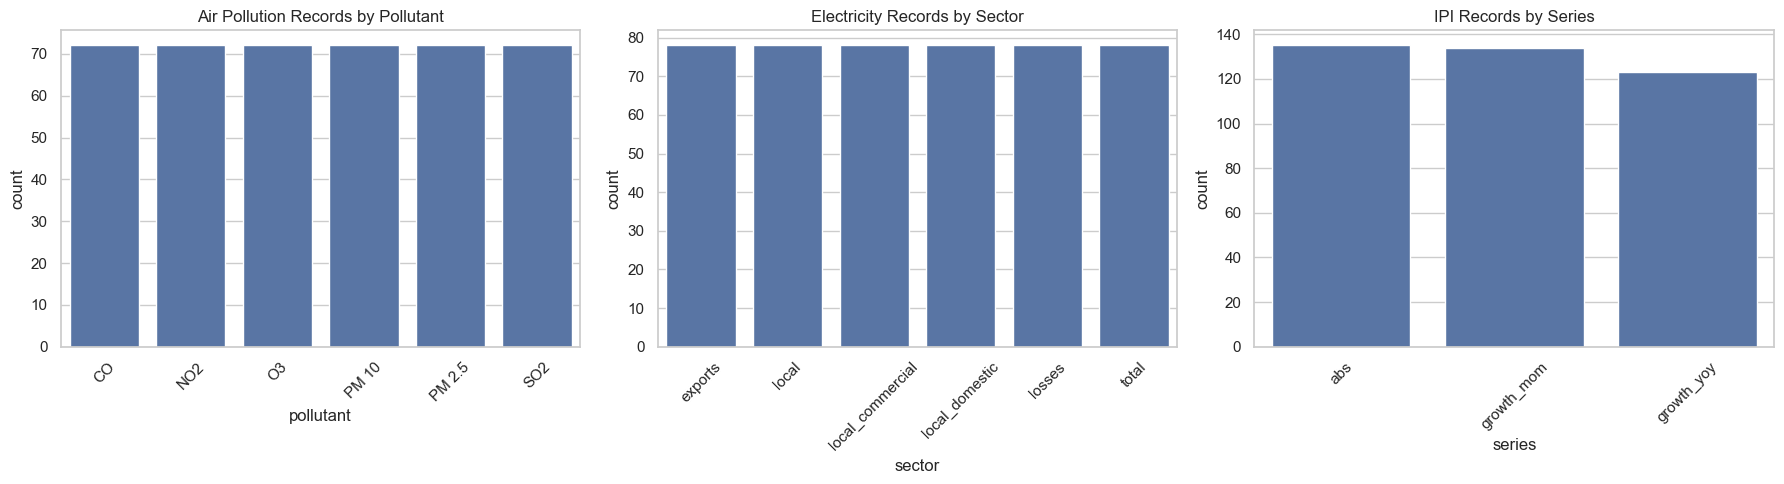

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
sns.countplot(data=air_raw, x="pollutant", order=sorted(air_raw["pollutant"].unique()), ax=axes[0])
axes[0].set_title("Air Pollution Records by Pollutant")
axes[0].tick_params(axis="x", rotation=45)
 
sns.countplot(data=electricity_raw, x="sector", order=sorted(electricity_raw["sector"].unique()), ax=axes[1])
axes[1].set_title("Electricity Records by Sector")
axes[1].tick_params(axis="x", rotation=45)
 
sns.countplot(data=ipi_raw, x="series", order=sorted(ipi_raw["series"].unique()), ax=axes[2])
axes[2].set_title("IPI Records by Series")
axes[2].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.show()


## Histograms
Histograms show each variable distribution and help reveal skewness, extreme values, and scale differences.

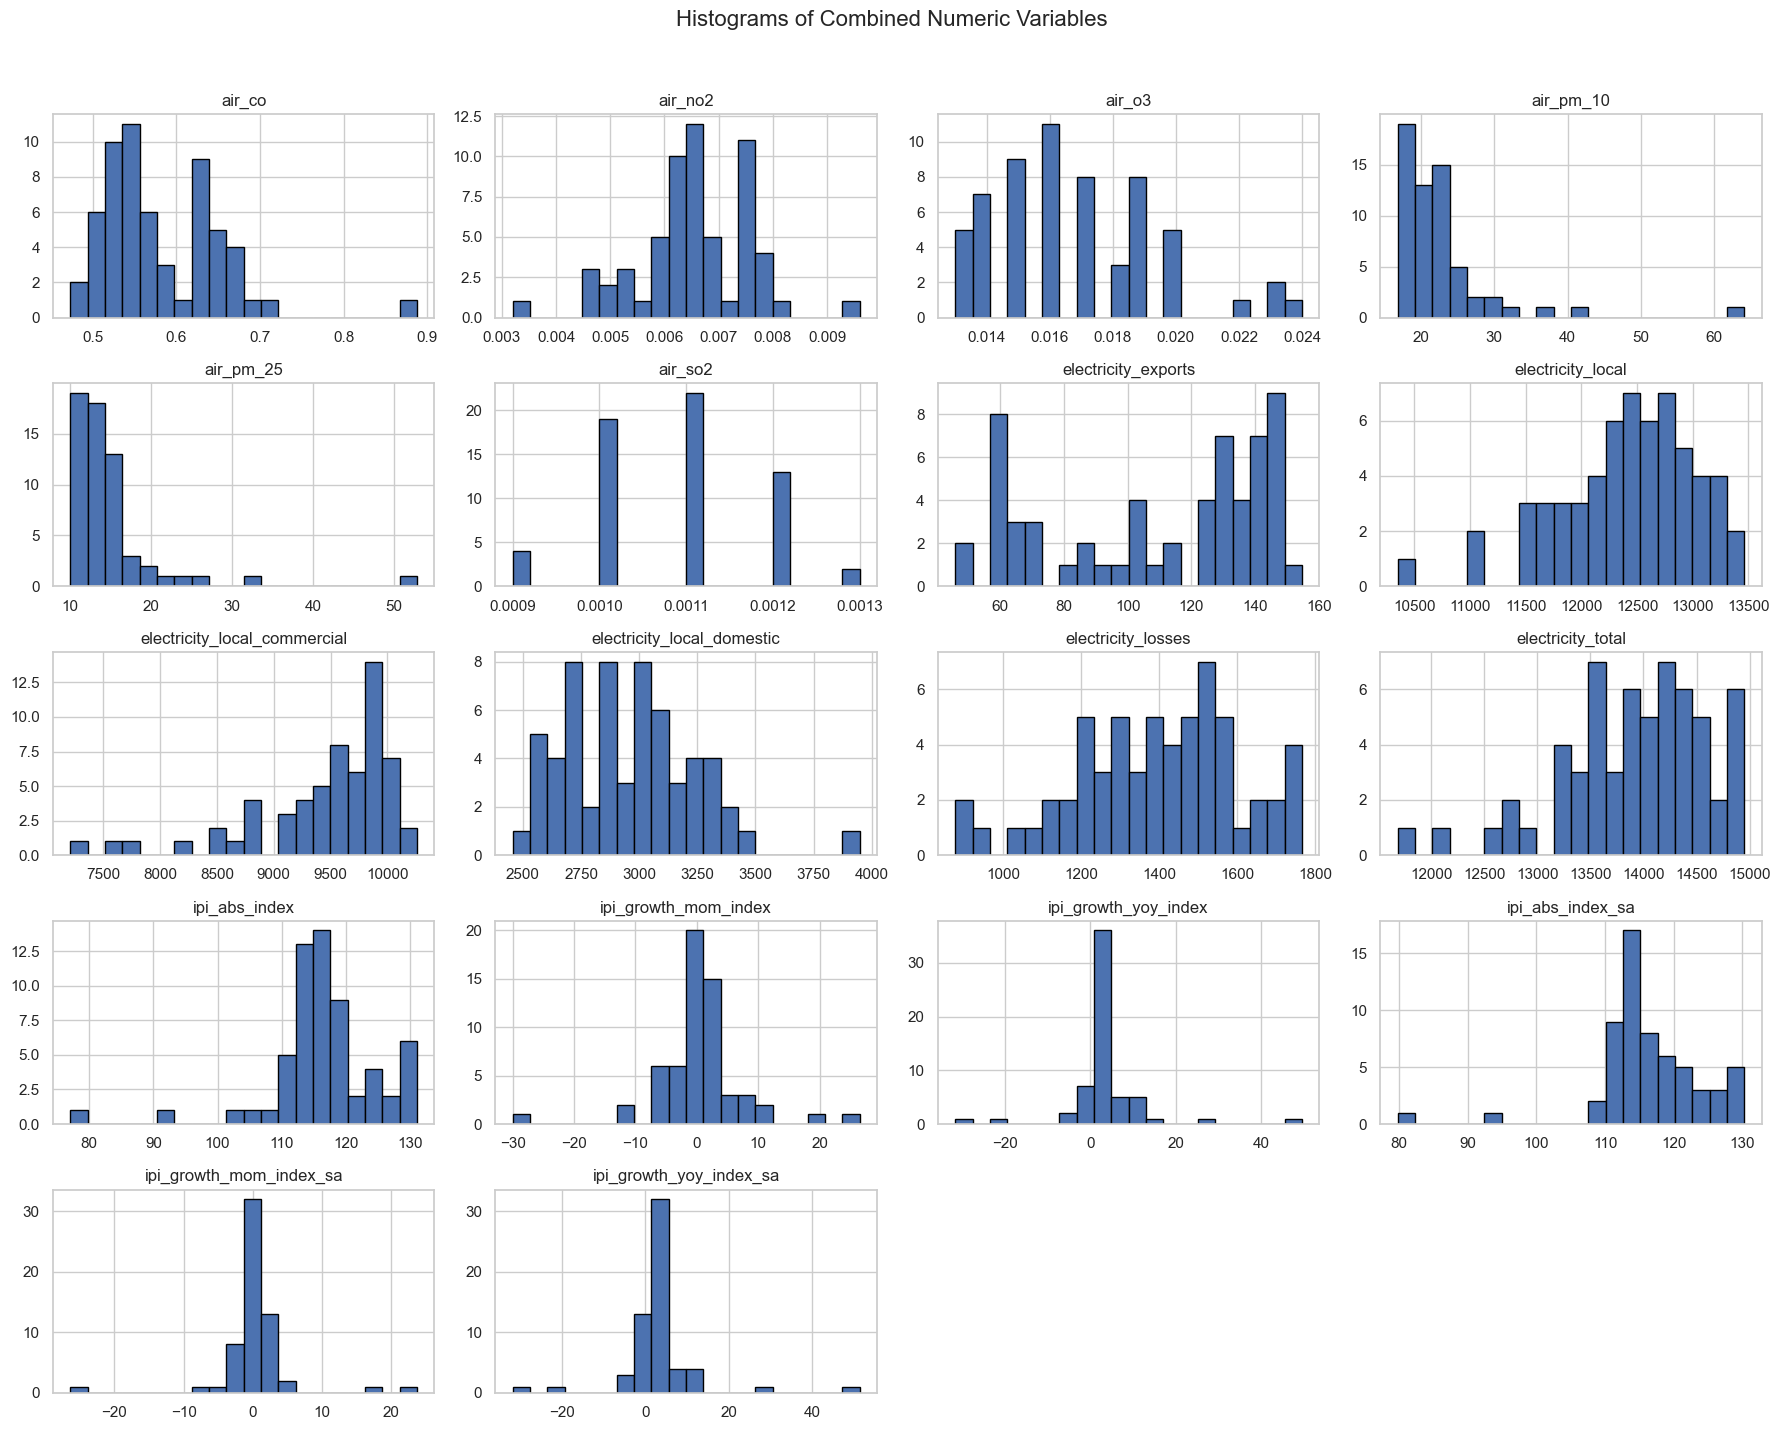

In [17]:
eda[numeric_cols].hist(bins=20, figsize=(18, 14), edgecolor="black")
plt.suptitle("Histograms of Combined Numeric Variables", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


## Boxplots
Because the columns are on very different scales, boxplots are grouped by domain.

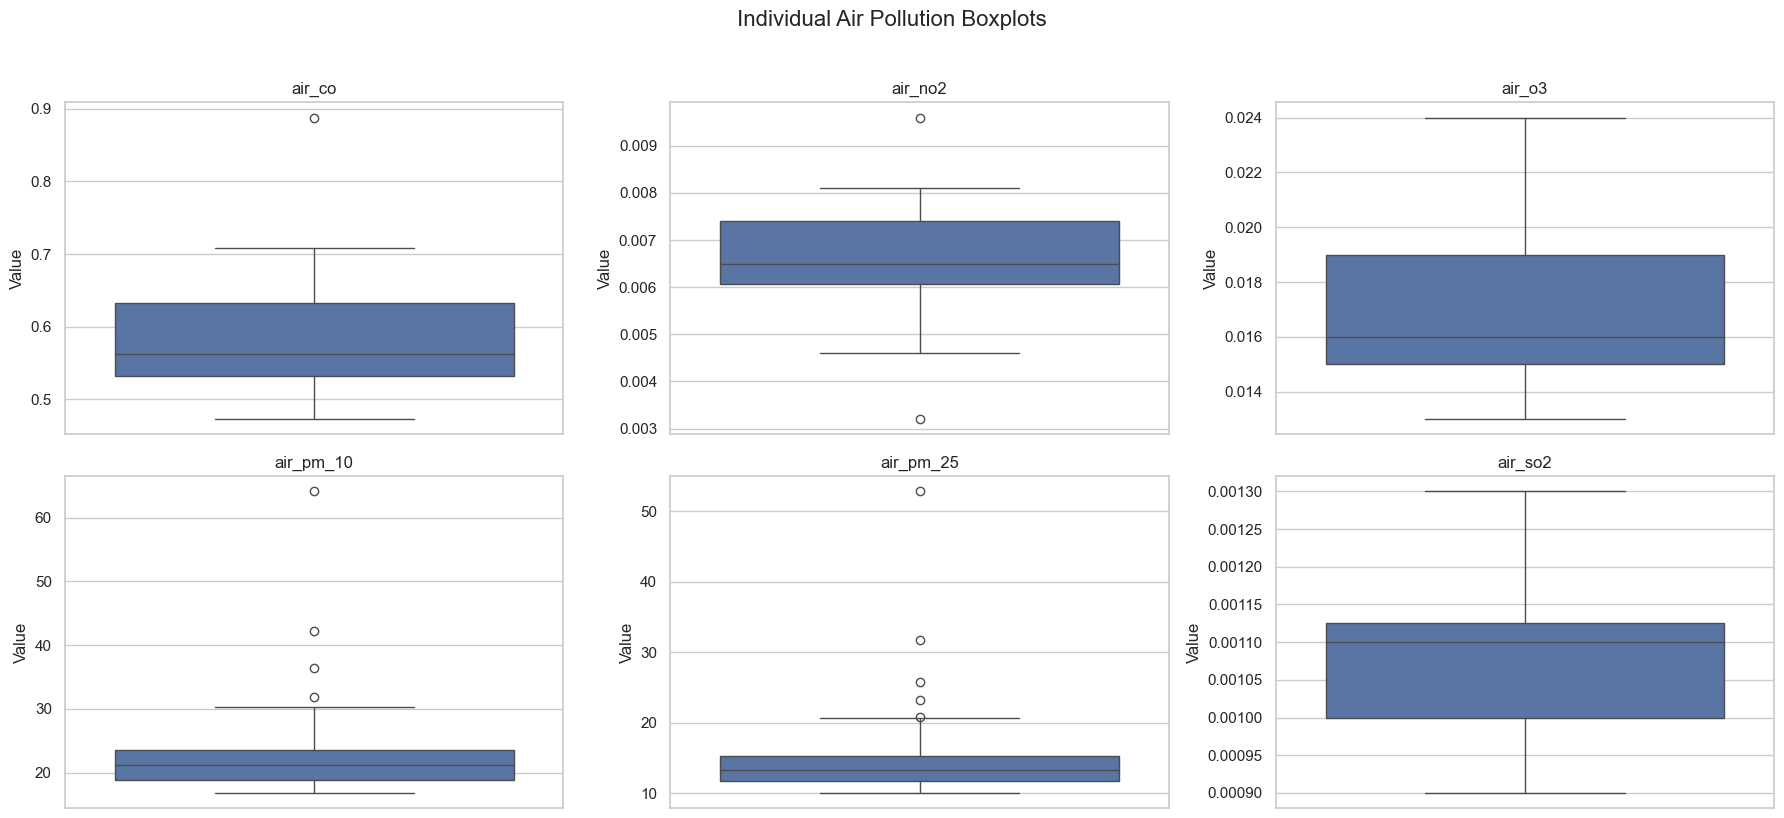

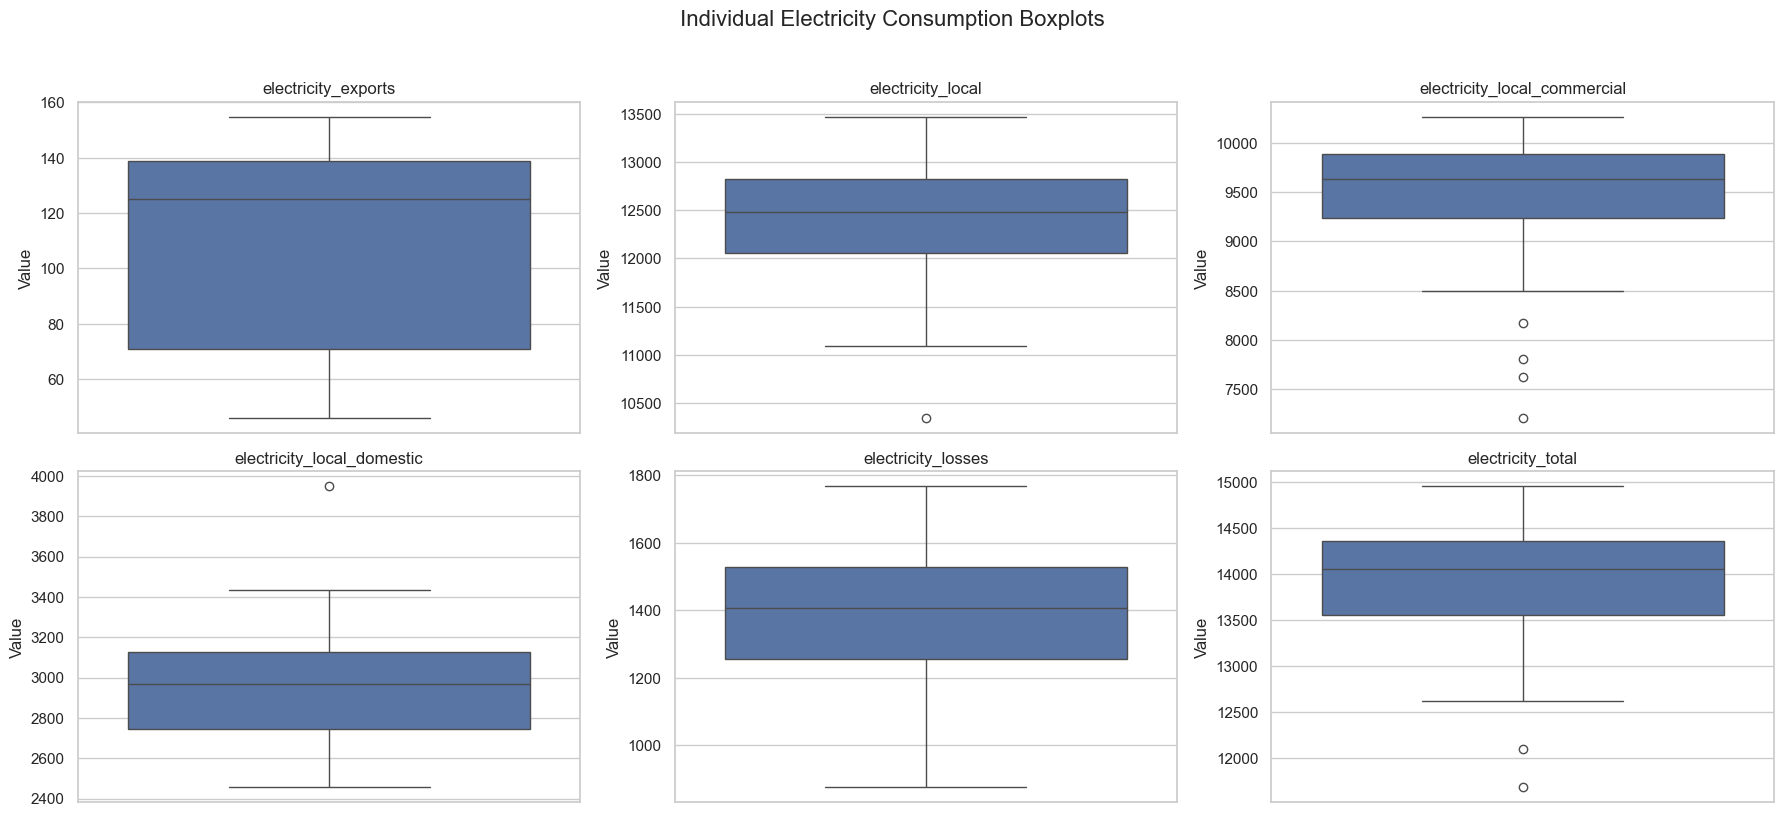

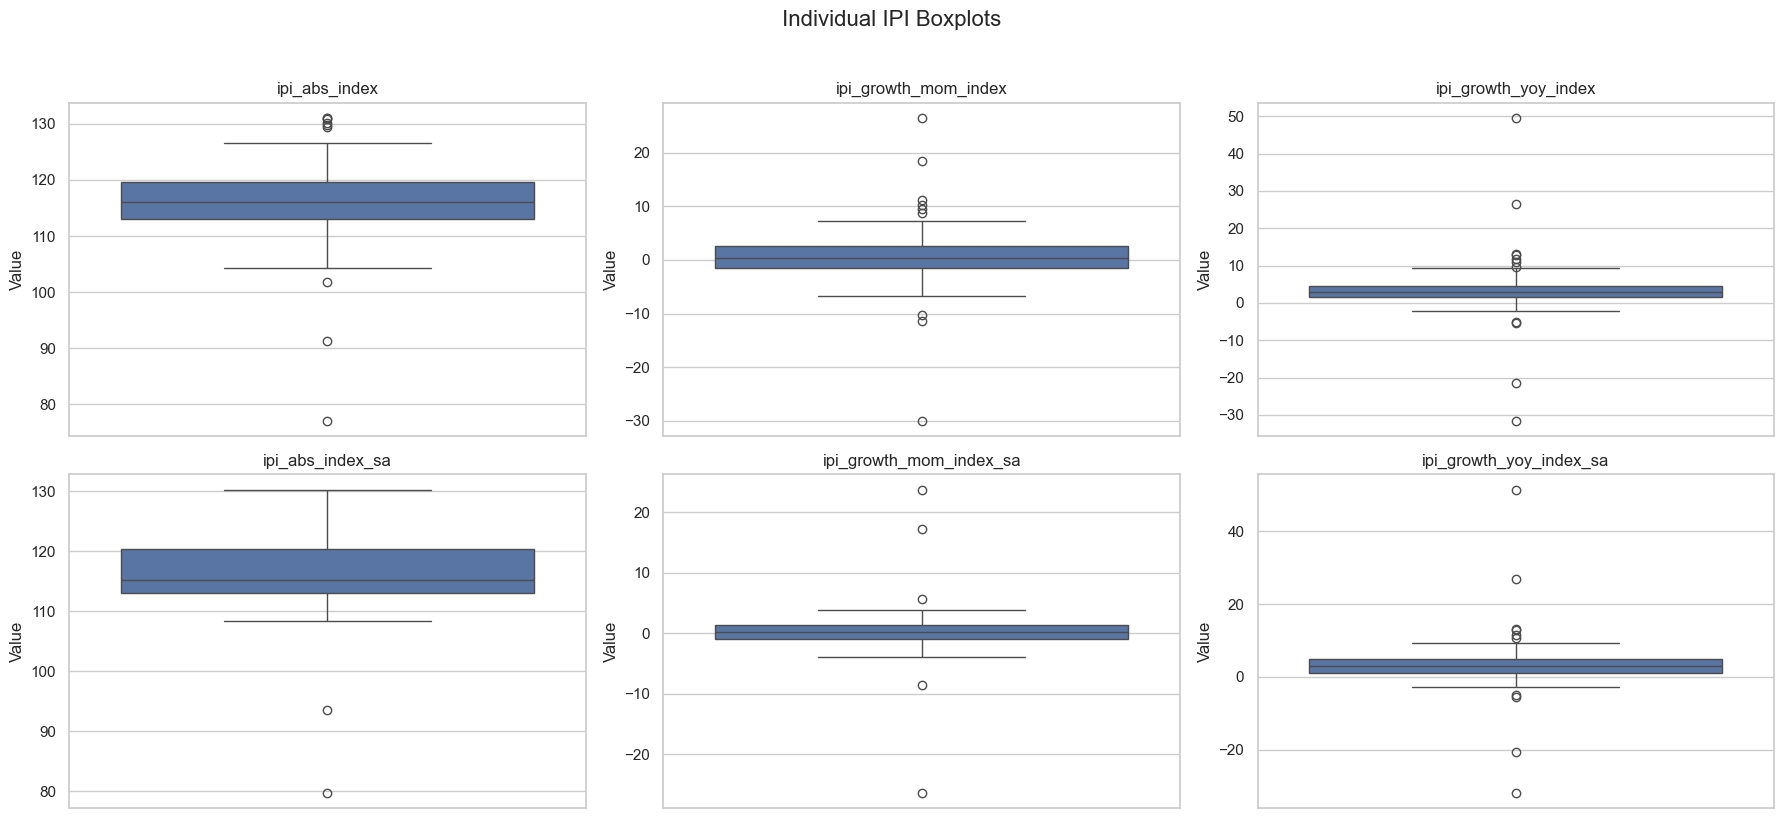

In [18]:
air_cols = [c for c in eda.columns if c.startswith("air_")]
electricity_cols = [c for c in eda.columns if c.startswith("electricity_")]
ipi_cols = [c for c in eda.columns if c.startswith("ipi_")]

plot_groups = {
    "Air Pollution": air_cols,
    "Electricity Consumption": electricity_cols,
    "IPI": ipi_cols,
}

for group_name, columns in plot_groups.items():
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, columns):
        sns.boxplot(y=eda[column], ax=ax)
        ax.set_title(column)
        ax.set_xlabel("")
        ax.set_ylabel("Value")

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle(f"Individual {group_name} Boxplots", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

## Scatterplots
These scatterplots compare electricity consumption against industrial production and selected air pollution indicators.

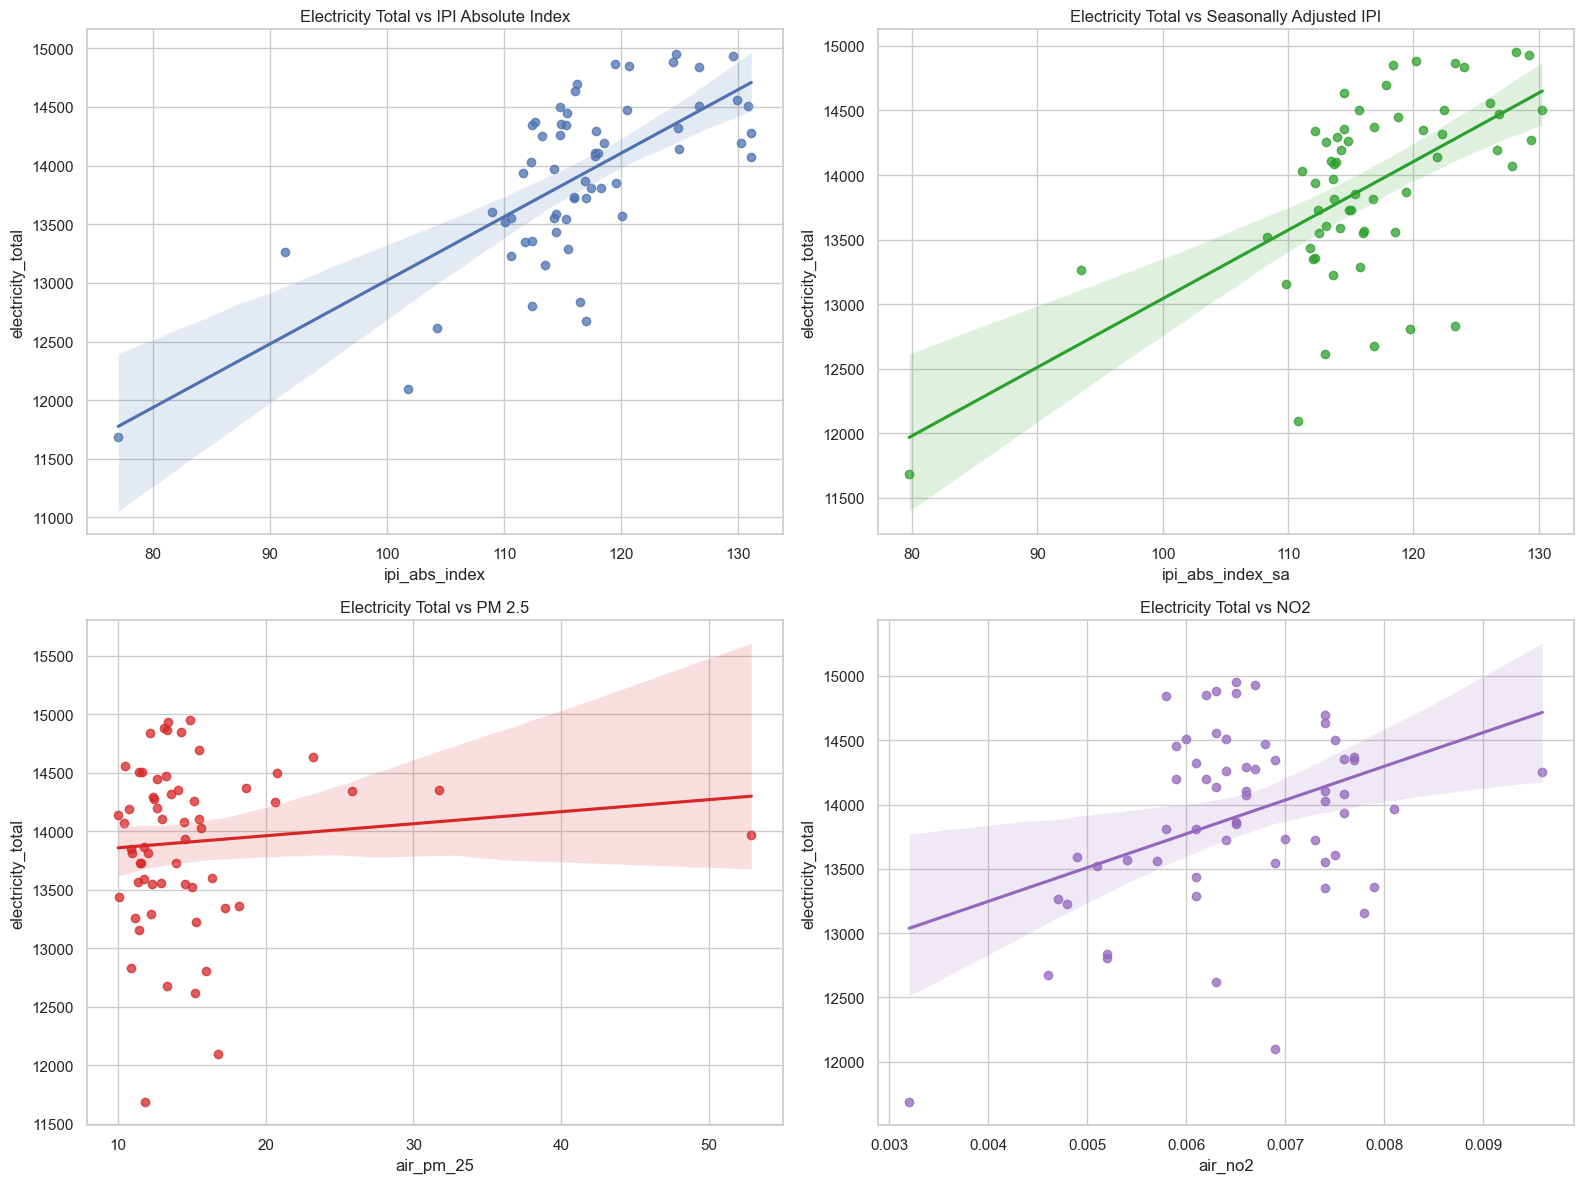

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
sns.regplot(data=eda, x="ipi_abs_index", y="electricity_total", ax=axes[0, 0], scatter_kws={"alpha": 0.75})
axes[0, 0].set_title("Electricity Total vs IPI Absolute Index")
 
sns.regplot(data=eda, x="ipi_abs_index_sa", y="electricity_total", ax=axes[0, 1], scatter_kws={"alpha": 0.75}, color="tab:green")
axes[0, 1].set_title("Electricity Total vs Seasonally Adjusted IPI")
 
sns.regplot(data=eda, x="air_pm_25", y="electricity_total", ax=axes[1, 0], scatter_kws={"alpha": 0.75}, color="tab:red")
axes[1, 0].set_title("Electricity Total vs PM 2.5")
 
sns.regplot(data=eda, x="air_no2", y="electricity_total", ax=axes[1, 1], scatter_kws={"alpha": 0.75}, color="tab:purple")
axes[1, 1].set_title("Electricity Total vs NO2")
 
plt.tight_layout()
plt.show()


## Pairplot
The full dataset has many numeric columns, so the pairplot uses representative variables to keep the plot readable.

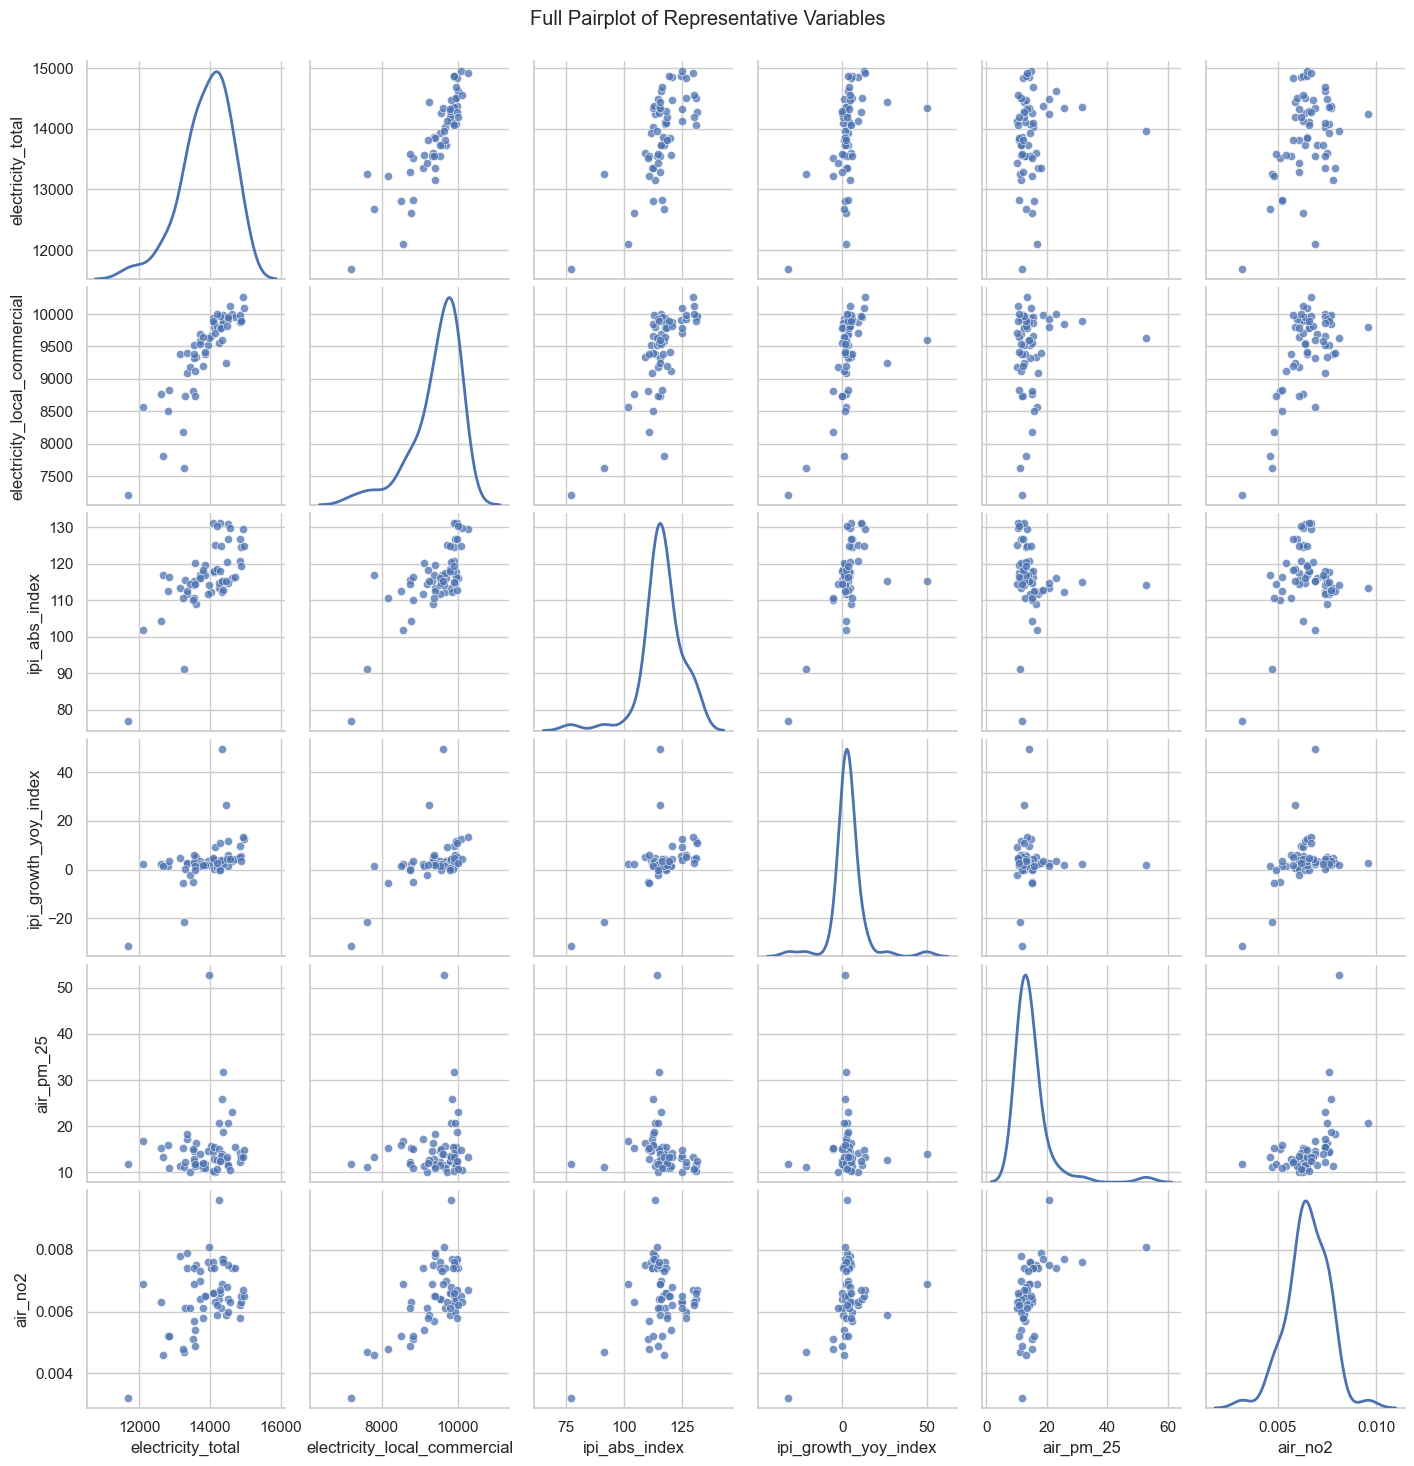

In [20]:
pairplot_cols = [
    "electricity_total",
    "electricity_local_commercial",
    "ipi_abs_index",
    "ipi_growth_yoy_index",
    "air_pm_25",
    "air_no2",
]

pair_grid = sns.pairplot(
    eda[pairplot_cols],
    diag_kind="kde",
    corner=False,
    height=2.4,
    plot_kws={"alpha": 0.75, "s": 35},
    diag_kws={"fill": False, "linewidth": 2},
)
pair_grid.fig.suptitle("Full Pairplot of Representative Variables", y=1.02)
plt.show()

## Correlation Heatmap
The heatmap helps identify strongly related variables and possible redundancy before modelling.

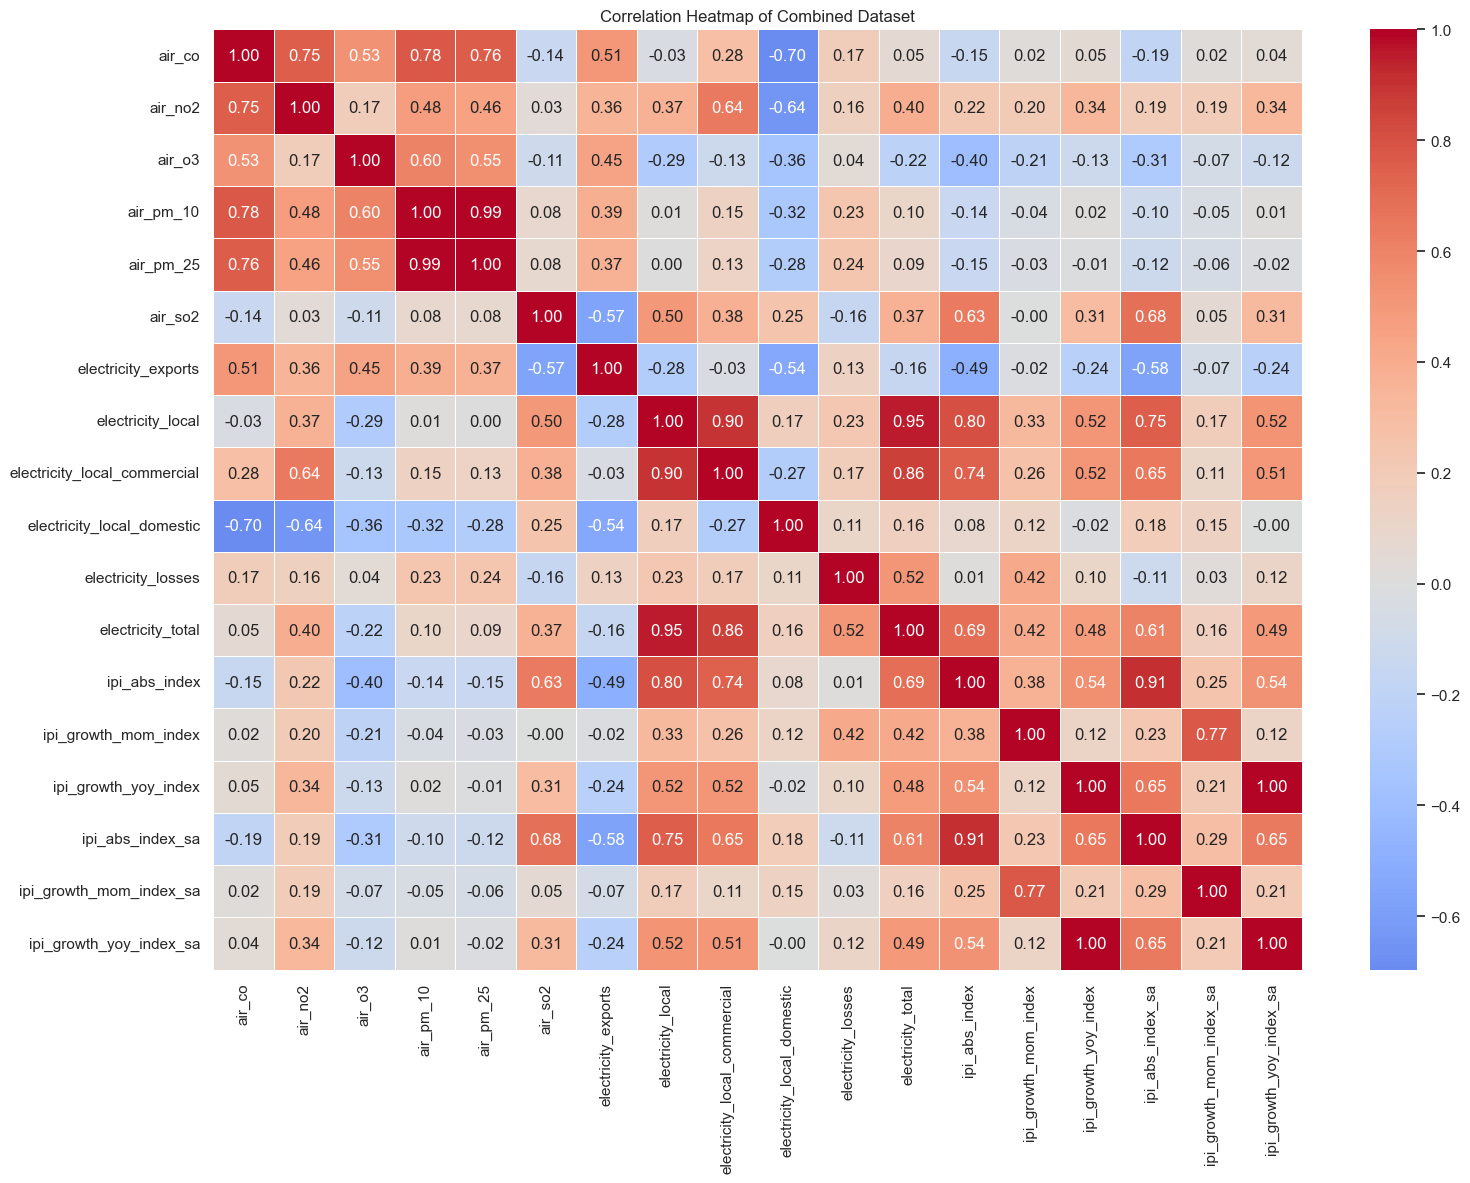

In [21]:
corr = eda[numeric_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Combined Dataset")
plt.tight_layout()
plt.show()


In [22]:
# Most correlated variables with electricity_total.
corr_with_total = corr["electricity_total"].drop("electricity_total").sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_with_total.to_frame("correlation_with_electricity_total"))


,correlation_with_electricity_total
electricity_local,0.949612
electricity_local_commercial,0.855821
ipi_abs_index,0.693769
ipi_abs_index_sa,0.608106
electricity_losses,0.518192
ipi_growth_yoy_index_sa,0.491776
ipi_growth_yoy_index,0.483838
ipi_growth_mom_index,0.418797
air_no2,0.395068
air_so2,0.371736


In [25]:
corr_with_total = corr["ipi_abs_index_sa"].drop("ipi_abs_index_sa").sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_with_total.to_frame("correlation_with_ipi_abs_index_sa"))


,correlation_with_ipi_abs_index_sa
ipi_abs_index,0.911395
electricity_local,0.750345
air_so2,0.676822
ipi_growth_yoy_index,0.651525
electricity_local_commercial,0.651449
ipi_growth_yoy_index_sa,0.647329
electricity_total,0.608106
electricity_exports,-0.575688
air_o3,-0.305454
ipi_growth_mom_index_sa,0.294883


## Time-Series Trend Check
A time plot is useful for this dataset because all rows are monthly observations.

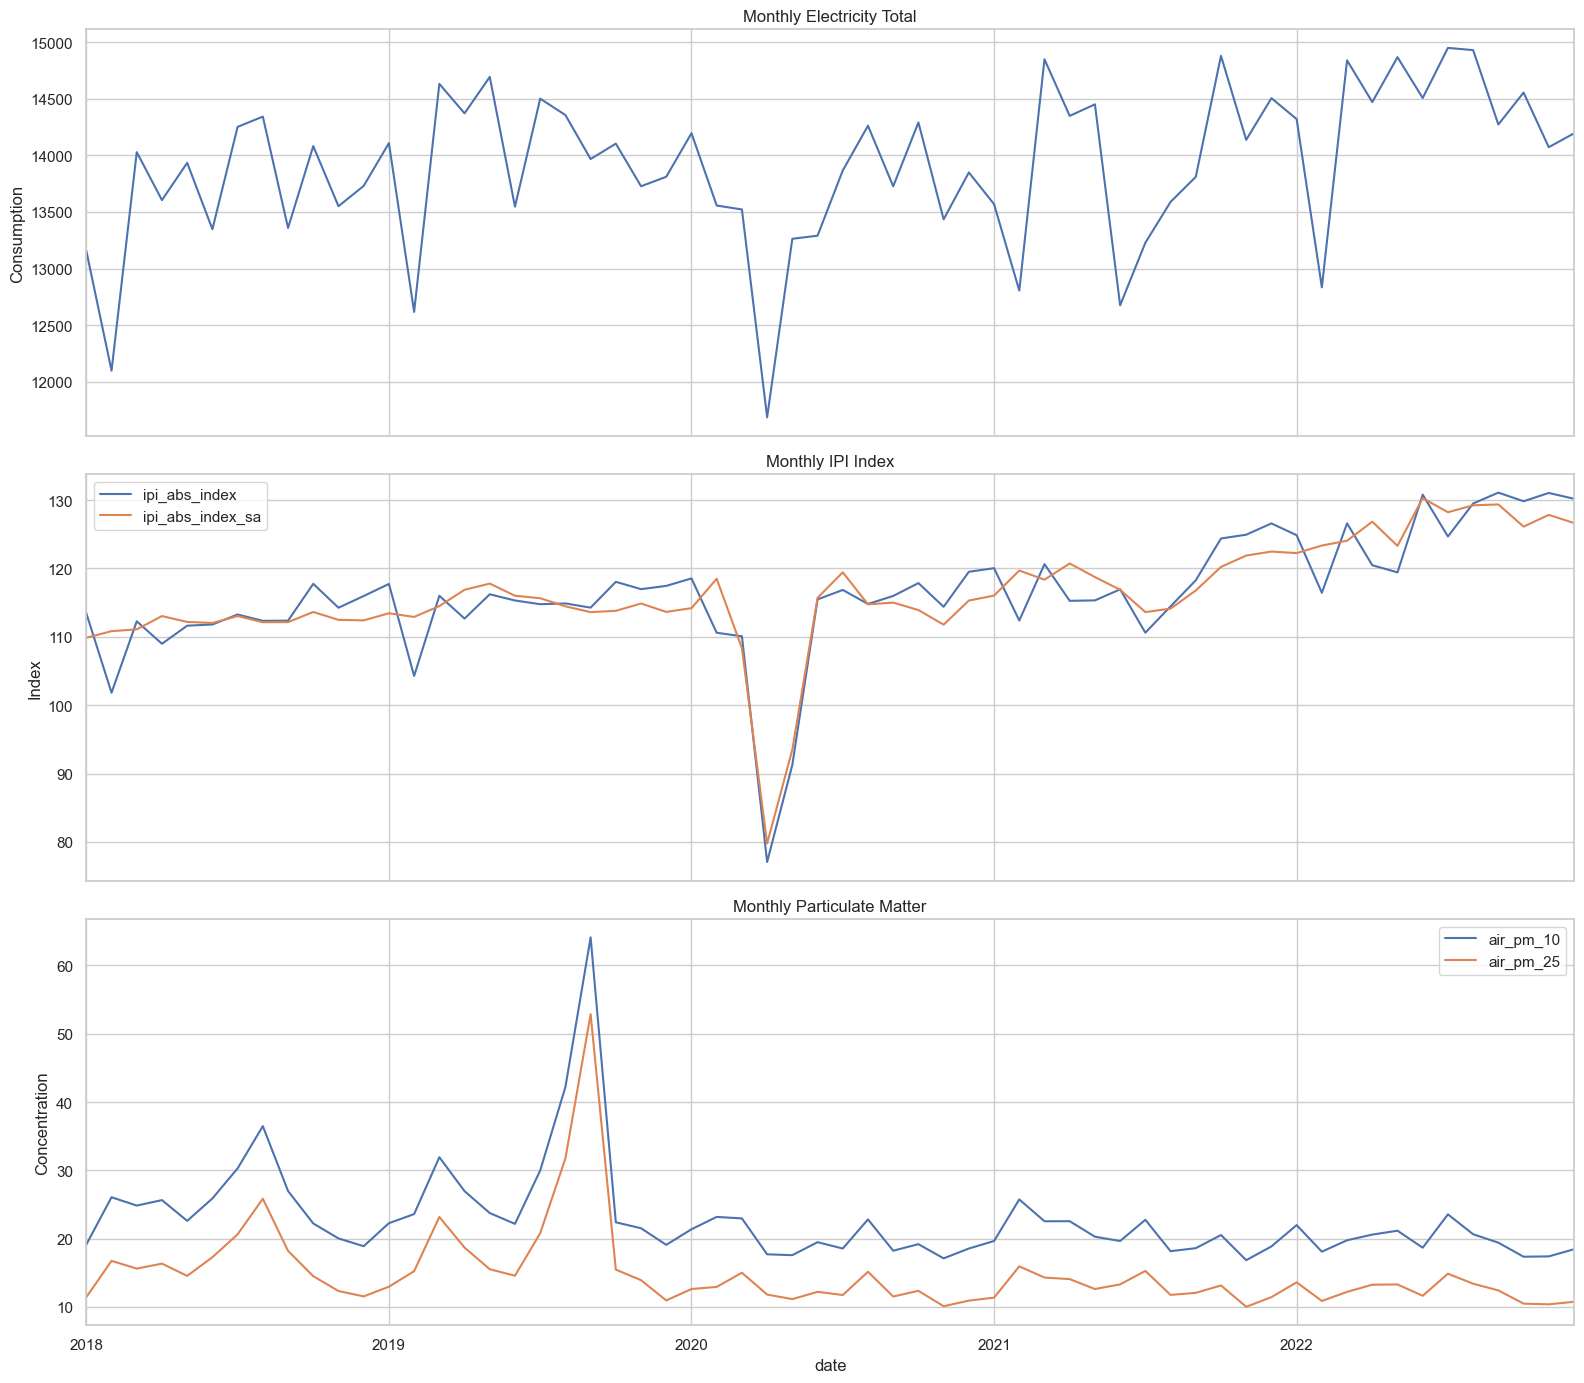

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
 
eda.plot(x="date", y="electricity_total", ax=axes[0], legend=False)
axes[0].set_title("Monthly Electricity Total")
axes[0].set_ylabel("Consumption")
 
eda.plot(x="date", y=["ipi_abs_index", "ipi_abs_index_sa"], ax=axes[1])
axes[1].set_title("Monthly IPI Index")
axes[1].set_ylabel("Index")
 
eda.plot(x="date", y=["air_pm_10", "air_pm_25"], ax=axes[2])
axes[2].set_title("Monthly Particulate Matter")
axes[2].set_ylabel("Concentration")
 
plt.tight_layout()
plt.show()
